# 1. 나를 찾아줘 - Class Activation Map 만들기


이번 시간에는 CAM(Class Activation Map)을 얻기 위한 방법 중 기본 CAM과 Grad-CAM을 구현해보고 이를 시각화해 보겠습니다. 그리고 CAM을 활용해서 물체의 위치를 찾는 object detection을 수행하고 이를 정답 데이터와 비교해 보겠습니다.

## 학습 내용
2. CAM, Grad-CAM용 모델 준비하기
- (1) 데이터셋 준비하기
    - CAM, Grad-CAM을 학습하기 위한 stanford_dogs Dataset을 준비합니다.
- (2) 물체의 위치정보
    - stanford_dogs의 BBox를 확인합니다.
- (3) CAM을 위한 모델 만들기
    - CAM 모델을 구현합니다.
- (4) CAM 모델 학습하기
    - CAM 모델을 학습합니다.
3. CAM
- 학습된 모델을 활용하여 CAM을 생성합니다.
4. Grad-CAM
- Grad-CAM을 이용해서 CAM을 얻어 시각화 합니다.
5. Detection with CAM
- CAM에서 물체의 위치를 찾는 detection을 시행합니다.
## 실습목표
- Classification model로부터 CAM을 얻어낼 수 있습니다.
- CAM으로 물체의 위치를 찾을 수 있습니다.
- CAM을 시각화 및 비교할 수 있습니다.

In [4]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 34.1 MB/s eta 0:00:0000:0100:01


# 2. CAM, Grad-CAM용 모델 준비하기
## (1) 데이터셋 준비하기
CAM(Class Activation Map) 은 특성을 추출하는 CNN 네트워크 뒤에 GAP(Global Average Pooling)와 소프트맥스 레이어(softmax layer)가 붙는 형태로 구성되어야 한다는 제약이 있습니다. 반면에 Grad-CAM은 이러한 제약이 없죠.

이번 시간에는 CAM과 Grad-CAM, 이 두 가지를 모두 구현해 보겠습니다.

우선 CAM을 위한 모델을 먼저 구성해 기본적인 CAM을 추출해보고, 이 모델에서 Grad-CAM을 활용해 다시 시각화 결과물을 추출하겠습니다. Grad-CAM은 모델의 구조에 제약이 없기 때문에 CAM에만 모델을 맞춰도 충분하기 때문입니다.

CAM은 클래스에 대한 활성화 정도를 나타낸 지도 입니다. 따라서 기본적으로 우리의 모델은 분류(classfication) 를 수행하는 모델이어야 합니다. 하지만 우리의 최종 목표는 이미지 내에서 클래스가 활성화 된 위치를 확인하고 이를 정답과 비교하는 것이므로 위치 정보가 기록된 데이터가 함께 있어야 합니다.

Tensorflow Datasets의 카탈로그에서 이러한 데이터를 확인할 수 있는데요. 여기서는 stanford_dogs 데이터셋을 사용하겠습니다. 이는 120 종의 개를 사진으로 판별하는 분류 문제 데이터셋으로, 라벨이 위치 정보인 바운딩 박스(bounding box) 정보를 포함하고 있습니다. 그럼 필요한 라이브러리와 데이터셋을 준비하고 시작하겠습니다.

In [3]:
# 1. 기존의 numpy 2.x 버전을 삭제합니다.
!pip uninstall numpy -y

# 2. 1.x 대의 가장 최신 안정 버전(1.26.4)을 설치합니다.
!pip install "numpy<2.0"

Found existing installation: numpy 2.5.0
Uninstalling numpy-2.5.0:
  Successfully uninstalled numpy-2.5.0


You can safely remove it manually.
You can safely remove it manually.


  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.


In [1]:
import os
import shutil
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch.nn.functional as F

import xml.etree.ElementTree as ET
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/lists.tar
!tar -xf images.tar -C work/class_activation_map/
!tar -xf annotation.tar -C work/class_activation_map/
!tar -xf lists.tar -C work/class_activation_map/

print("데이터 다운로드 완료!")

--2026-06-25 07:19:34--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘images.tar’

images.tar          100%[===================>] 756.82M  6.19MB/s    in 92s     

2026-06-25 07:21:06 (8.24 MB/s) - ‘images.tar’ saved [793579520/793579520]

--2026-06-25 07:21:06--  http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21852160 (21M) [application/x-tar]
Saving to: ‘annotation.tar’

annotation.tar      100%[===================>]  20.84M  5.33MB/s    in 5.4s    

2026-06-25 07:21:12 (3.85 MB/s) - ‘annotat

Stanford Dogs 데이터셋은 다음과 같이 구성되어있습니다.

Images 폴더
각 폴더 내에는 class 별 폴더로 구성되어있고 내부에는 이미지가 저장되어있습니다.
Annotation 폴더
Images와 마찬가지로 class 별 폴더로 구성되어있고 내부에는 각 이미지에 대한 메타데이터가 저장되어있습니다.
list.mat 파일
각 파일 내에는 train/test 셋의 파일명이 정리되어있습니다.
이후 학습에 활용하기 위해 train/test list.mat 파일을 바탕으로 각 데이터를 train과 test로 나눠야합니다.
최종적으로는 데이터 폴더는 다음과 같이 구성됩니다.

- stanford_dogs ┬train ┬class 1
                        ├class 2
                        ├class 3
                            ...
                └test  ┬class 1
                        ├class 2
                        ├(중략)
                            ...

In [4]:
# 원본 데이터 경로 (압축 해제 후 폴더)
images_dir ='work/class_activation_map/Images'   # 이미지들이 위치한 폴더
mat_dir = 'work/class_activation_map'   # 프로젝트 루트 디렉토리

# .mat 파일 경로 (train_list.mat와 test_list.mat가 각각 같은 구조라고 가정)
train_mat_path = os.path.join(mat_dir, 'train_list.mat')
test_mat_path = os.path.join(mat_dir, 'test_list.mat')

# .mat 파일 로드
train_mat = sio.loadmat(train_mat_path)
test_mat = sio.loadmat(test_mat_path)

# train_mat와 test_mat 내부에 'file_list'와 'labels' 등이 있음
train_file_list = train_mat['file_list']
train_labels = train_mat['labels'].squeeze()  # (N,)
test_file_list = test_mat['file_list']
test_labels = test_mat['labels'].squeeze()

# 최종적으로 ImageFolder 구조로 재구성할 대상 폴더 생성 (예: stanford_dogs/train, stanford_dogs/test)
base_dir = 'stanford_dogs'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

def process_mat_file(file_list_array, split_dir):
    """
    .mat 파일에서 로드한 file_list_array를 사용해,
    split_dir(예: train 혹은 test)에 클래스별 폴더를 생성하고 이미지를 복사합니다.
    """
    num_files = file_list_array.shape[0]
    for idx in range(num_files):
        # file_list_array[idx]는 보통 array([<파일경로>]) 형태입니다.
        # 따라서, array([<파일경로>]).item()을 사용하면 실제 문자열을 얻을 수 있습니다.
        file_path = file_list_array[idx][0].item()

        # 혹시 bytes 타입이면 문자열로 디코딩
        if isinstance(file_path, bytes):
            file_path = file_path.decode('utf-8')

        # 파일 경로 예시: 'n02116738-African_hunting_dog/n02116738_2988.jpg'
        # 클래스 이름은 파일 경로의 최상위 폴더명 (예: 'n02116738-African_hunting_dog')
        class_folder = file_path.split('/')[0]

        # 대상 클래스 폴더 생성
        dest_folder = os.path.join(split_dir, class_folder)
        os.makedirs(dest_folder, exist_ok=True)

        # 원본 이미지 경로: Images 폴더 아래에 file_path 위치
        src_path = os.path.join(images_dir, file_path)
        # 대상 이미지 경로: dest_folder 아래에 원본 파일명 그대로 복사
        dest_path = os.path.join(dest_folder, os.path.basename(file_path))

        # 파일 존재 여부 확인 후 복사
        if os.path.exists(src_path):
            shutil.copy(src_path, dest_path)
        else:
            print(f"File not found: {src_path}")

print("Processing train set...")
process_mat_file(train_file_list, train_dir)
print("Processing test set...")
process_mat_file(test_file_list, test_dir)

print("Dataset reorganization complete.")

Processing train set...
Processing test set...
Dataset reorganization complete.


그런데 이 데이터를 읽어올 때 파일명만 바뀌는 것이 아니라 다음과 같이 데이터의 경로까지 바뀌게 됩니다.

stanford_dogs/train/클래스명/파일명.jpg

그렇다고 클래스 별 폴더로 구성하지 않으면 class에 대한 정보를 별도로 보관해야합니다.(다만 이 데이터셋은 annotation 파일 내에 저장되어있습니다.) 이럴때 쉽게 사용할 수 있는 라이브러리를 소개하도록 하겠습니다.

torchvision.datasets.ImageFolder는 class, 즉 label이 폴더명으로 구성되어있는 데이터 구성을 사용하기 쉽게 변환해주는 라이브러리입니다. 파이토치 도큐먼트를 확인해주세요.

다만 여기에서는 추가로 annotation 부분이 포함되어야하기 때문에 torchvision.datasets.ImageFolder를 약간 손봐서 사용하도록 하겠습니다.

In [5]:
class StanfordDogsDatasetWithBBox(datasets.ImageFolder):
    def __init__(self, root, annotation_root, transform=None):
        super().__init__(root, transform=transform)
        self.annotation_root = annotation_root  # 예: '/content/Annotation'
        self.new_size = (224, 224)

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _ = self.samples[index]

        rel_path = os.path.relpath(path, self.root)
        annot_filename = os.path.splitext(os.path.basename(rel_path))[0]
        annot_folder = os.path.dirname(rel_path)
        annot_path = os.path.join(self.annotation_root, annot_folder, annot_filename)

        # bbox 기본값 (예: [ymin, xmin, ymax, xmax])
        bbox = [0.0, 0.0, 0.0, 0.0]

        if os.path.exists(annot_path):
            try:
                # 확장자가 없지만 XML 형식의 파일이라고 가정하고 파싱
                tree = ET.parse(annot_path)
                root_xml = tree.getroot()
                # 첫 번째 object 태그에서 bndbox 정보를 읽음
                obj = root_xml.find('object')
                if obj is not None:
                    bndbox = obj.find('bndbox')
                    if bndbox is not None:
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        # XML 내 <size> 태그에서 원본 이미지 크기 획득
                        size = root_xml.find('size')
                        w = float(size.find('width').text)
                        h = float(size.find('height').text)
                        new_h, new_w = self.new_size
                        # bbox 좌표 순서: [ymin, xmin, ymax, xmax]
                        bbox = [xmin * (new_w / w), ymin * (new_h / h),
                                xmax * (new_w / w), ymax * (new_h / h)]
                    else:
                        print(f"bndbox 태그를 찾을 수 없습니다: {annot_path}")
                else:
                    print(f"object 태그를 찾을 수 없습니다: {annot_path}")
            except Exception as e:
                print(f"Error parsing {annot_path}: {e}")
        else:
            print(f"Annotation file not found: {annot_path}")

        return image, label, bbox

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 데이터셋 경로 (재구성한 ImageFolder 형식)
train_dir = os.path.join('stanford_dogs', 'train')
test_dir = os.path.join('stanford_dogs', 'test')
# Annotation 폴더 경로 (예: '/root/Annotation')
annotation_dir ='work/class_activation_map/Annotation'

# 커스텀 데이터셋 생성: image, label, bbox 반환
train_dataset = StanfordDogsDatasetWithBBox(root=train_dir, annotation_root=annotation_dir, transform=transform)
valid_dataset = StanfordDogsDatasetWithBBox(root=test_dir, annotation_root=annotation_dir, transform=transform)

batch_size = 12
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(valid_dataset)}")

Number of classes: 120
Train samples: 12000
Test samples: 8580


In [7]:
def visualize(sample):
    img_tensor, label, bbox = sample

    # 인덱스와 클래스 정보
    print("Label index:", label)
    print("Class name:", train_dataset.classes[label])

    # 정규화 복원 전처리 시 사용한 평균과 표준편차
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # tensor의 shape: (C, H, W) -> (H, W, C)
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    plt.figure(figsize=(6,6))
    plt.imshow(img_np)
    plt.title(f"Class: {train_dataset.classes[label]}")
    plt.axis('off')
    plt.show()

Label index: 0
Class name: n02085620-Chihuahua


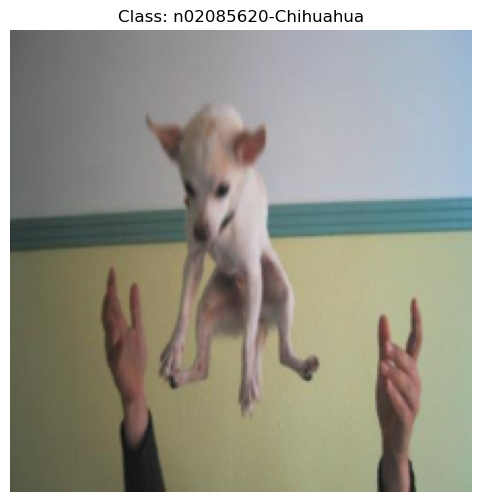

In [8]:
# 임의의 한 샘플 선택 (여기서는 첫 번째 샘플을 사용)
train_sample = train_dataset[0]

visualize(train_sample)

학습용 데이터셋 뿐만 아니라 평가용 데이터셋도 눈으로 확인해 보세요.

Label index: 0
Class name: n02085620-Chihuahua


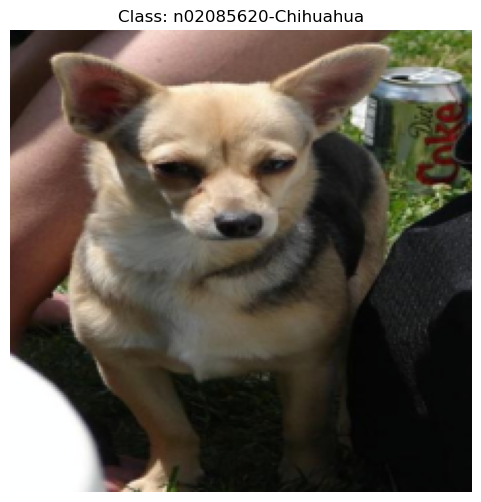

In [9]:
# 임의의 한 샘플 선택 (여기서는 첫 번째 샘플을 사용)
test_sample = valid_dataset[0]

visualize(test_sample)

## (2) 물체의 위치정보
원본 이미지 위에 물체의 위치정보는 어떻게 시각화하여 표시할 수 있을까요? 이미지와 함께 다운로드받은 annotation 하나를 확인해봅시다.

In [10]:
# Annotation 폴더에서 데이터를 골라보세요
annotation_path = 'work/class_activation_map/Annotation/n02085620-Chihuahua/n02085620_10074'


# XML 파일 파싱
tree = ET.parse(annotation_path)
root = tree.getroot()

for elem in root.iter():
    print(f"{elem.tag}: {elem.text}")

annotation: 
	
folder: 02085620
filename: n02085620_10074
source: 
		
database: ImageNet database
size: 
		
width: 333
height: 500
depth: 3
segment: 0
object: 
		
name: Chihuahua
pose: Unspecified
truncated: 0
difficult: 0
bndbox: 
			
xmin: 25
ymin: 10
xmax: 276
ymax: 498


먼저 folder와 filename는 annotation와 연관된 이미지 파일의 정보를 나타냅니다. source는 해당 파일의 출처로 예시로 가져온 파일은 ImageNet에서 가져온 것으로 보입니다.

size의 경우 원본 이미지의 크기를 나타내며 segment는 이미지가 Segmentation Mask와 연관될 경우 사용되는데 0으로 된 경우 별도의 Segmentation 정보는 없다는 것을 의미합니다.

object에 담긴 정보는 name, pose, truncated, difficult, bndbox로 각각 다음과 같은 의미를 갖고 있습니다.

name 객체의 클래스 이름을 나타냅니다. 여기서는 'Chihuahua'로, 해당 객체가 치와와 품종의 개임을 의미합니다.
pose 객체의 자세(orientation)를 나타내며, 여기서는 'Unspecified'로 구체적인 자세 정보는 제공되지 않습니다.
truncated 객체가 이미지 경계에 의해 잘려(truncated) 있는지 여부를 나타냅니다. 0은 잘리지 않았음을 의미합니다.
difficult 객체 인식이 어려운 정도를 나타내는 플래그로, 0은 비교적 인식하기 쉬운 객체임을 의미합니다.
bndbox 객체의 위치를 사각형 영역(바운딩 박스)으로 나타내는 정보입니다.
<xmin>25</xmin>: 바운딩 박스의 왼쪽 경계 (가로 좌표)

<ymin>10</ymin>: 바운딩 박스의 상단 경계 (세로 좌표)

<xmax>276</xmax>: 바운딩 박스의 오른쪽 경계 (가로 좌표)

<ymax>498</ymax>: 바운딩 박스의 하단 경계 (세로 좌표)

이 좌표들은 원본 이미지의 픽셀 기준 값이며, 이를 이용해 물체의 위치와 크기를 정확하게 파악할 수 있습니다.

이 좌표점을 원본 이미지와 함께 나타내면 다음과 같이 보일 것입니다.

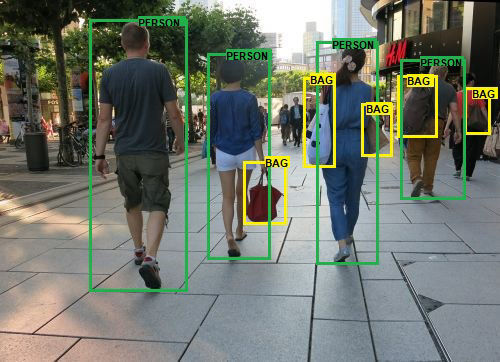

바운딩 박스를 표시하는 방법들
바운딩 박스를 라벨링하는 방법은 아주 다양합니다. 그 중 주로 사용되는 방법은 'xywh' 또는 'minmax'로 표기하는 방법입니다.

'xywh' 는 바운딩박스 중심점을 x, y로 표기하고, 사각형의 너비 w와 높이 h를 표기하는 방법입니다.
(예) (x_center, y_center, width, height)
x, y가 중심점이 아니라 좌측 상단의 점을 가리킬 수도 있습니다.
'minmax'는 바운딩박스를 이루는 좌표의 최소값과 최대값을 통해 표기하는 방법입니다.
(예) (x_min, x_max, y_min, y_max)
좌표의 절대값이 아니라, 전체 이미지의 너비와 높이를 기준으로 normalize한 상대적인 값을 표기하는 것이 일반적입니다.
위 두가지 뿐만 아니라 이미지의 상하좌우 끝단으로부터 거리로 표현하는 방법, 좌우측의 x값과 상하측의 y값 네 개로 표시하는 방법(LRTB), 네 점의 x, y 좌표 값을 모두 표시하는 방법(QUAD) 등 여러 가지 방법이 있습니다. 따라서 새로운 데이터셋을 접하거나 라이브러리를 활용하실 때는 간단한 바운딩 박스 정보라도 한 번 더 표기법을 확인하고 넘어가는 것이 좋습니다.


## (3) CAM을 위한 모델 만들기
이번에는 본격적으로 CAM을 얻어내기 위한 모델을 만들어 보겠습니다. 미리 이미지넷(ImageNet) 데이터에 훈련된 ResNet50을 기반으로 하고, 이후 pooling layer 뒤에 소프트맥스 레이어를 붙여 Grad-CAM 모델을 만들겠습니다.

참고로, 소프트맥스 레이어는 소프트맥스 함수를 활성화 함수로 사용하는 fully connected 레이어입니다.

구현해 보기
아래에서 직접 ResNet50 뒤에 필요한 레이어를 붙여 CAM을 구하기 위한 기본 모델을 완성해 주세요. CAM 모델의 구조가 생각나지 않는다면, Lecture 노드나 관련 내용을 참고해 완성해 보세요.

In [11]:
model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
model = model.to(device)

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 142MB/s]


CAM 모델은 우리가 해왔던 분류 문제를 위한 모델과 크게 다른 점이 없습니다.

torchvision.models.resnet50
아래에서 직접 만든 CAM모델을 확인해 주세요.

In [12]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Q. CAM은 특성 맵(feature map)을 사용해 만듭니다. 위 레이어들 중 우리가 사용하는 특성 맵은 어떤 레이어의 출력값일까요? 해당 레이어의 이름을 찾아보세요.

📝 주관식 퀴즈 제출용 답변 (텍스트 복사용)
CAM을 생성할 때 사용하는 특성 맵은 모델의 가장 마지막 컨볼루션 레이어(Convolutional Layer)의 출력값입니다.

실습 코드에서 기반으로 사용하고 있는 ResNet50 모델 구조를 기준으로 본다면, 마지막 블록에 해당하는 layer4의 출력값이 우리가 사용하는 최종 특성 맵이 됩니다.

CAM은 이미지의 위치 정보(Spatial information)가 살아있는 상태에서 클래스 가중치를 곱해야 합니다.  
ResNet50에서 layer4 이후에 연결되는 avgpool (Global Average Pooling) 레이어를 거치면 공간 정보가 $1 \times 1$ 크기로 압축되어 사라집니다.  
따라서 공간(위치) 정보가 풍부하게 남아있으면서도 가장 고차원의 추상적인 특징을 담고 있는 layer4 (마지막 컨볼루션 레이어)의 출력을 특성 맵으로 사용합니다.

## (4) CAM 모델 학습하기
이제 학습을 위한 과정은 이전과 비슷합니다.

이제 모델을 컴파일하고 학습시킵시다. 여기서는 맛보기로 2 Epoch 만 학습시켜 봅시다.😊 (뒷 부분에서는 미리 준비해둔 학습된 가중치를 불러와서 모델에 적용할 예정입니다.)

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [14]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        print(f"\nEpoch {epoch+1}/{num_epochs} 시작")
        for batch_idx, (images, labels, _) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            if (batch_idx + 1) % 50 == 0:
                print(f"  Step {batch_idx+1} - Loss: {loss.item():.4f}")

        train_loss = running_loss / (batch_idx + 1)
        train_acc = correct / total
        print(f"Train - Loss: {train_loss:.4f}, Accuracy: {train_acc*100:.2f}%")

        # 검증 단계
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels, _ in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
        test_loss = running_loss / len(valid_loader)
        test_acc = correct / total
        print(f"Validation - Loss: {test_loss:.4f}, Accuracy: {test_acc*100:.2f}%")

In [18]:
%%time

train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2)


Epoch 1/2 시작
  Step 50 - Loss: 3.4918
  Step 100 - Loss: 4.2672
  Step 150 - Loss: 3.6239
  Step 200 - Loss: 3.0397
  Step 250 - Loss: 2.5287
  Step 300 - Loss: 3.9654
  Step 350 - Loss: 3.4197
  Step 400 - Loss: 2.5880
  Step 450 - Loss: 3.3750
  Step 500 - Loss: 3.2604
  Step 550 - Loss: 2.7577
  Step 600 - Loss: 2.4452
  Step 650 - Loss: 2.6966
  Step 700 - Loss: 1.0651
  Step 750 - Loss: 2.9429
  Step 800 - Loss: 2.5376
  Step 850 - Loss: 2.9180
  Step 900 - Loss: 2.8875
  Step 950 - Loss: 2.5058
  Step 1000 - Loss: 3.4274
Train - Loss: 3.1715, Accuracy: 22.61%
Validation - Loss: 2.7829, Accuracy: 29.71%

Epoch 2/2 시작
  Step 50 - Loss: 1.6317
  Step 100 - Loss: 2.1877
  Step 150 - Loss: 1.6919
  Step 200 - Loss: 2.0862
  Step 250 - Loss: 2.7816
  Step 300 - Loss: 3.2457
  Step 350 - Loss: 2.3912
  Step 400 - Loss: 2.1914
  Step 450 - Loss: 2.7345
  Step 500 - Loss: 3.2656
  Step 550 - Loss: 1.7026
  Step 600 - Loss: 2.3835
  Step 650 - Loss: 1.9406
  Step 700 - Loss: 2.6350
  Step

In [19]:
cam_model_path = "work/class_activation_map/cam_model.pt"

In [20]:
# Q. '/work/class_activation_map' 에 'cam_model1.h5'을 저장하세요.

cam_model_path = "work/class_activation_map/cam_model.pt"

torch.save(model, cam_model_path)

# 3. CAM
이제 학습된 모델을 활용하여 CAM을 생성해 볼 것입니다. 학습에 사용한 이미지는 이미 전처리를 거쳤기 때문에 다음 전처리 코드가 필요합니다.

In [21]:
def unnormalize(img_tensor):
    """
    img_tensor: [C, H, W] 텐서 (전처리 상태, 예: normalization 적용됨)
    ImageNet 평균 및 표준편차를 이용하여 복원 (RGB 순서)
    """
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    return img

In [22]:
# 원하는 데이터를 골라서 진행해보세요

image, label, bbox = train_dataset[0]
sample_image = image.unsqueeze(0).to(device)

In [23]:
# 모델을 불러오세요

# [[YOUR CODE]]
model = torch.load(cam_model_path, weights_only=False)

CAM(클래스 활성화 맵)을 생성하기 위해서는 세 가지 핵심 요소가 필요합니다.

- 특성 맵(Feature Map)
    네트워크의 특정 합성곱 계층(여기서는 layer4)에서 추출한 특징 정보를 의미합니다. 이 정보는 입력 이미지의 다양한 공간적 패턴을 담고 있습니다.

- 소프트맥스 레이어의 가중치
    분류기(fully-connected layer)에서 각 클래스에 대해 학습된 가중치들은, 해당 클래스가 가지는 특징이 어느 정도 기여하는지를 나타냅니다. 즉, 특정 클래스에 대한 확률 예측에 얼마나 중요한지를 반영합니다.

- 원하는 클래스의 출력값
    네트워크의 최종 출력에서 실제로 예측된 클래스, 또는 관심있는 클래스의 값을 사용하여, 해당 클래스에 집중하는 영역(즉, 모델이 어느 부분에 주목하는지)을 결정합니다.
    이 함수에서는 위의 요소들을 기반으로 CAM을 계산합니다. 구체적인 과정은 다음과 같습니다.

1. 특정 레이어의 출력 추출
    model.layer4에 forward hook을 등록하여, 네트워크의 feedforward 과정 중에 해당 합성곱 계층의 출력(특성 맵)을 features 리스트에 저장합니다.

2. 모델의 예측 수행 및 원하는 클래스 선택
    입력 이미지를 모델에 전달하여 feedforward를 수행하고, 출력 결과에서 배치 내 첫 번째 이미지에 대해 가장 높은 점수를 가진 클래스를 선택합니다.

3. 가중치와 특성 맵의 가중합을 통한 CAM 계산
    선택한 클래스에 해당하는 fully-connected layer의 가중치(소프트맥스 레이어의 역할을 하는 fc 레이어의 가중치)를 사용하여, 저장된 특성 맵의 각 채널과 곱셈을 수행합니다. 이렇게 채널별로 가중합을 계산하면, 해당 클래스에 기여하는 공간적 중요 영역을 반영한 CAM이 만들어집니다.

4. 정규화 및 (옵션) 리사이즈
    계산된 CAM에 ReLU를 적용하고, 최소/최대 값을 이용해 정규화합니다. 또한, 모델이 출력한 CAM의 크기는 보통 입력 이미지보다 작기 때문에, 이를 시각화하려면 입력 이미지와 동일한 크기로 리사이즈하는 것이 유용합니다. (코드에서는 리사이즈 과정은 포함되어 있지 않지만, 필요에 따라 cv2.resize 등을 사용하여 후처리할 수 있습니다.)

In [24]:
def generate_cam(model, image):
    model.eval()
    features = []

    def hook(module, input, output):
        features.append(output.detach())
    hook_handle = model.layer4.register_forward_hook(hook)

    output = model(image)
    hook_handle.remove()

    # 예측된 클래스 선택 (배치의 첫 번째 이미지 기준)
    pred_class = output.argmax(dim=1).item()

    # 모델의 fc layer 가중치가 모델과 동일한 디바이스에 있도록 처리
    fc_weights = model.fc.weight.data.to(image.device)

    # features[0]: shape [1, num_features, H, W]
    fmap = features[0][0]  # 첫 번째 이미지의 feature map
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=image.device)

    # fc 가중치와 feature map의 각 채널을 가중합
    for i, w in enumerate(fc_weights[pred_class]):
        cam += w * fmap[i, :, :]
    cam = cam.cpu().numpy()

    # CAM 정규화
    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

    return cam

In [25]:
cam = generate_cam(model, sample_image)

In [26]:
#이제 위에서 작성한 함수를 실행하면 아래와 같은 CAM을 얻을 수 있습니다. 이것만으로는 제대로 동작하는 것인지 파악하기 어렵습니다.
def visualize_cam(cam):
    plt.imshow(cam, cmap='jet')
    plt.colorbar()
    plt.title("CAM")
    plt.axis('off')
    plt.show()

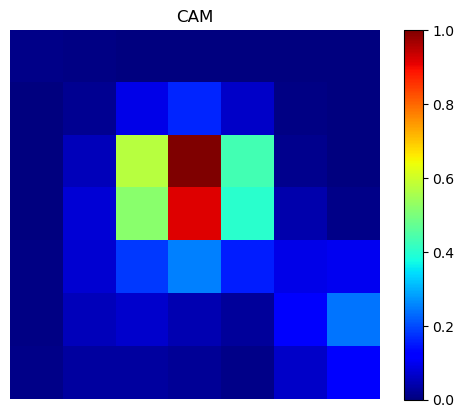

In [27]:
visualize_cam(cam)

In [28]:
def visualize_cam_on_image(cam, img, alpha=0.5):
    # CAM 크기를 원본 이미지 크기로 조정
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

    # CAM을 컬러 heatmap으로 변환 (cv2.applyColorMap는 BGR로 반환하므로 RGB로 변경)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # 원본 이미지와 heatmap을 alpha blending
    overlay = heatmap * alpha + img * (1 - alpha)
    overlay = overlay.astype(np.uint8)

    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("CAM Overlay on Image")
    plt.axis('off')
    plt.show()

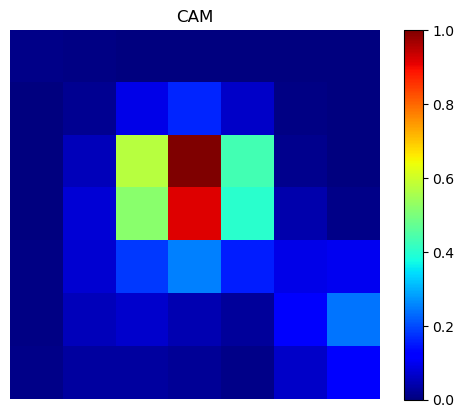

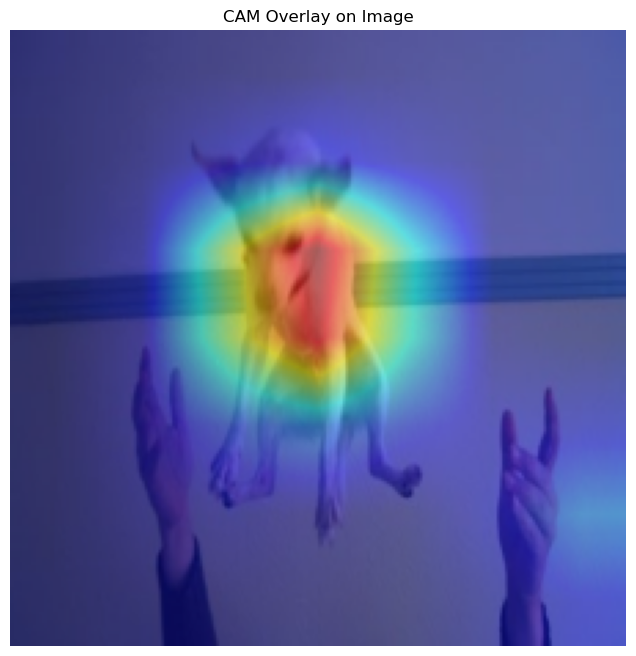

In [29]:
# 원본 이미지 복원
orig_img = unnormalize(image)

# CAM 단독 시각화
visualize_cam(cam)

# 원본 이미지 위에 CAM overlay 시각화
visualize_cam_on_image(cam, orig_img)

어떤가요? 생성된 CAM이 개를 식별하는데 중요한 이미지 부분을 잘 포착하고 있나요? 주로 강아지의 얼굴과 몸통이 있는 부분이 강조되는 경향이 있는데, 이것은 사람이 개를 식별할 때 유의해서 보는 부분과 일맥상통합니다.

# 4. Grad-CAM
이번에는 Grad-CAM을 이용해서 CAM을 얻어보도록 하겠습니다. 적용 모델을 유연하게 선택할 수 있는 Grad-CAM의 특성 상 위에서 만들었던 모델을 다시 활용해도 괜찮기 때문에 관찰 대상 모델은 cam_model을 그대로 활용합시다.

우선 새로운 이미지를 적용해보고 싶다면 로드해주세요.

이번에는 Grad-CAM을 이용해서 CAM을 만들어 봅시다.

grad_cam은 관찰을 원하는 레이어와 정답 클래스에 대한 예측값 사이의 그래디언트를 구하고, 여기에 GAP 연산을 적용함으로써 관찰 대상이 되는 레이어의 채널별 가중치를 구합니다. 최종 CAM 이미지를 구하기 위해서는 레이어의 채널별 가중치(weights)와 레이어에서 나온 채널별 특성 맵을 가중합해주어 cam_image를 얻게 됩니다.

이전 스텝에서 본 CAM 함수와 달리, Grad-CAM은 이번에는 어떤 레이어든 CAM 이미지를 뽑아낼 수 있으므로, 그래디언트 계산을 원하는 관찰 대상 레이어 activation_layer를 뽑아서 쓸 수 있도록 activation_layer의 이름을 받고 이를 활용해야 합니다.

아래 generate_grad_cam()에서는 원하는 레이어의 output과 특정 클래스의 prediction 사이의 그래디언트 grad_val을 얻고 이를 weights로 활용합니다.

In [30]:
def generate_grad_cam(model, image, target_layer_name):
    model.eval()
    features = {}
    gradients = {}

    # forward hook: 대상 레이어의 출력을 저장
    def forward_hook(module, input, output):
        features['value'] = output.detach()

    # backward hook: 대상 레이어의 gradient를 저장
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    # 모델 내에서 이름이 target_layer_name과 일치하는 레이어 검색
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    # hook 등록
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_backward_hook(backward_hook)

    # 순전파 실행
    output = model(image)
    pred_class = output.argmax(dim=1).item()

    # 예측 클래스에 대해 backward 수행
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # hook 제거
    forward_handle.remove()
    backward_handle.remove()

    # 저장된 feature map과 gradient 추출 (shape: [C, H, W])
    fmap = features['value'][0]
    grads = gradients['value'][0]

    # 각 채널에 대해 gradient의 global average pooling 계산 (weight 역할)
    weights = torch.mean(grads, dim=(1, 2))

    # weighted sum: 각 채널의 feature map에 weight를 곱해 합산
    grad_cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device)
    for i, w in enumerate(weights):
        grad_cam += w * fmap[i, :, :]
    grad_cam = grad_cam.cpu().numpy()

    # ReLU 적용 및 정규화: 음수 값 제거 및 [0,1] 범위로 스케일링
    grad_cam = np.maximum(grad_cam, 0)
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)

    return grad_cam

/opt/conda/lib/python3.12/site-packages/torch/nn/modules/module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


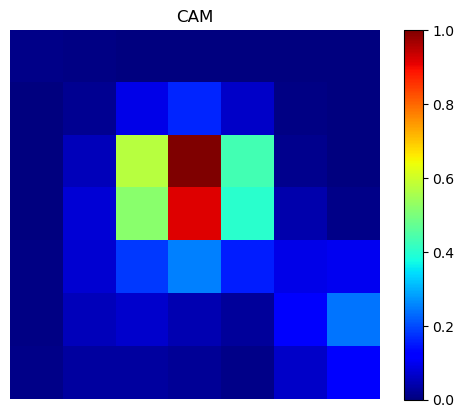

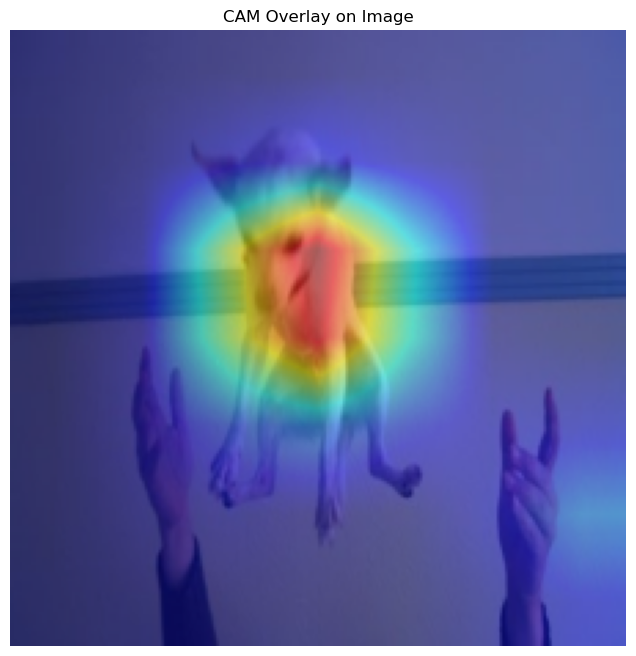

In [31]:
# layer4 사용
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

## Q. 위 코드에서 layer4 를 사용하는 이유를 생각해봅시다.
layer4는 ResNet 등 CNN 모델의 가장 깊은(마지막) 컨볼루션 레이어이기 때문입니다. CNN의 후반부 레이어일수록 객체의 전체적인 형태나 추상적인 의미 정보(Semantic Information)를 풍부하게 담고 있어, 모델이 '무엇을 보고 정답을 예측했는지' 시각화하는 Grad-CAM의 목적에 가장 부합합니다.

조금 더 자세한 이유 (이해를 돕기 위한 설명)
풍부한 추상적 정보 (High-level Features): layer1이나 layer2 같은 앞부분의 레이어는 이미지의 선, 면, 질감 같은 저수준(Low-level) 특징만 학습합니다. 반면, 마지막인 layer4 쯤 오면 고양이의 귀, 자동차의 바퀴처럼 객체의 구체적인 형상과 클래스를 구분할 수 있는 고수준 정보를 가지고 있습니다.

공간적 정보(Spatial Information)의 유지: Fully Connected Layer(전결합층)로 넘어가기 직전의 활성화 맵(Feature Map)이기 때문에, 이미지의 어느 위치가 중요했는지 공간적 위치 정보를 그대로 간직하고 있습니다.

Grad-CAM의 효과 극대화: 따라서 layer4를 지정해야만 모델이 특정 클래스(정답)를 예측할 때 "이미지의 어느 영역(객체)을 가장 중요하게 보았는지"를 가장 정확하고 직관적인 히트맵으로 얻을 수 있습니다.

이제 만든 함수로 여러 레이어의 CAM 이미지를 뽑아서 직접 확인해보세요! 레이어의 이름은 이전 스탭의 model 출력 결과값에서 찾을 수 있습니다.

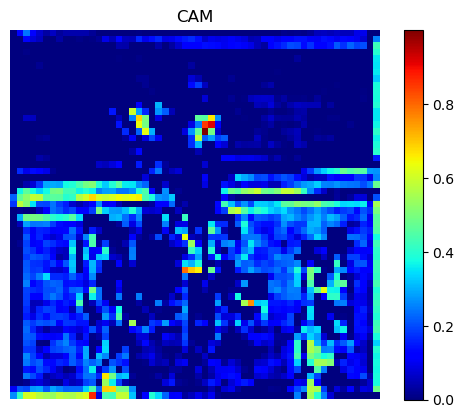

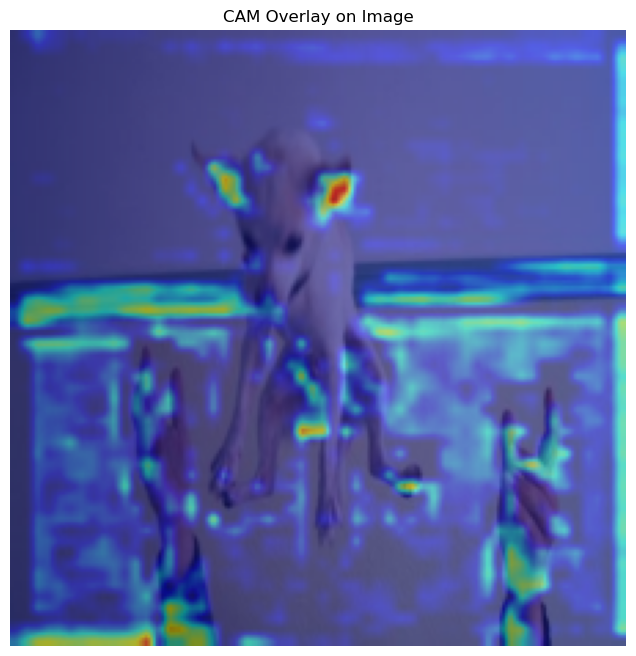

In [32]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer1")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

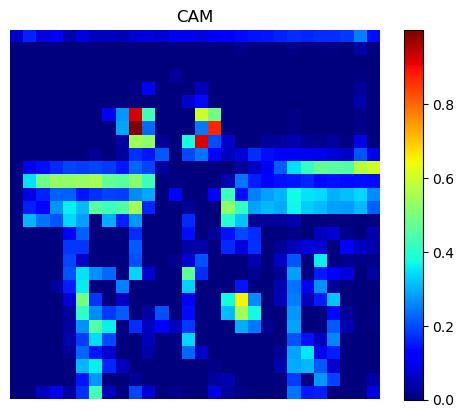

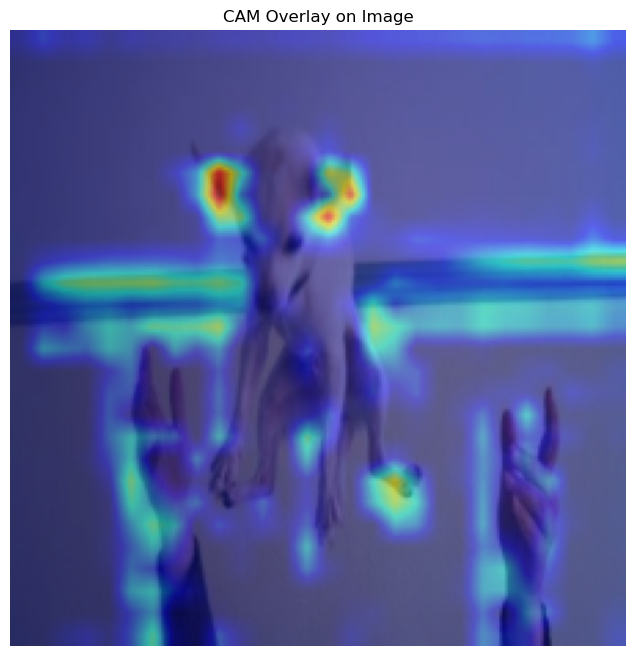

In [33]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer2")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

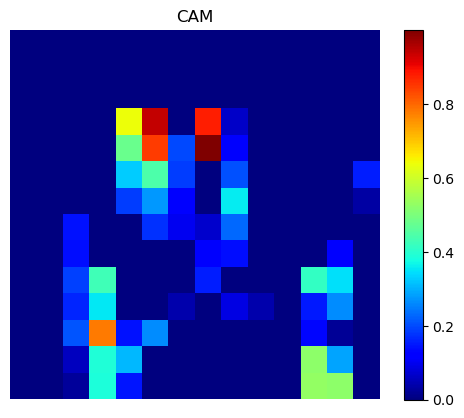

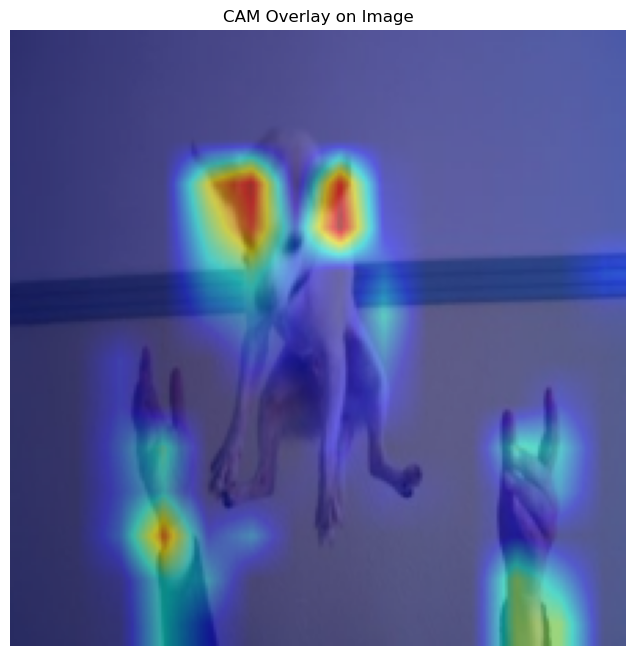

In [34]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer3")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

# 5. Detection with CAM
바운딩 박스
마지막으로 이번에는 CAM에서 물체의 위치를 찾는 detection을 해 보도록 하겠습니다.

우선 새로운 이미지를 다시 뽑아 CAM 이미지를 뽑아봅시다.

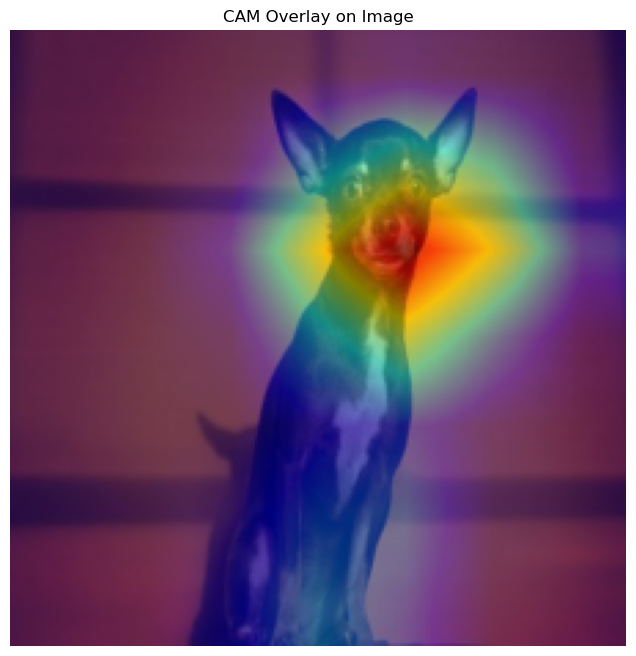

In [35]:
image, label, ground_bbox = train_dataset[10]
sample_image = image.unsqueeze(0).to(device)
orig_img = unnormalize(image)
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")

visualize_cam_on_image(grad_cam, orig_img)

이전 스텝에서 만들었던 generate_cam()을 활용해서 CAM 이미지를 뽑았습니다. 아래 get_bbox() 함수는 바운딩 박스를 만들기 위해서 score_thresh를 받아 역치값 이하의 바운딩 박스는 없앱니다.

In [36]:
def get_bbox(cam, threshold=0.01):
    coords = np.argwhere(cam > threshold)
    if coords.size == 0:
        return None
    # np.argwhere의 결과는 (row, col) 즉, (y, x) 순서입니다.
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return (x_min, y_min, x_max, y_max)

In [37]:
cam_resized = cv2.resize(cam, (orig_img.shape[1], orig_img.shape[0]))
bbox = get_bbox(cam_resized, threshold=0.5)

print(bbox)

(np.int64(76), np.int64(61), np.int64(139), np.int64(131))


아래에서 cam_image를 통해 bbox를 얻고 이를 이미지 위에 시각화한 모습을 볼 수 있습니다.

In [38]:
def visualize_bbox_on_image(img, bbox, box_color=(255, 0, 0), thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()
    if bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), box_color, thickness)
    else:
        print("활성화된 영역이 없습니다.")
    return img_with_bbox

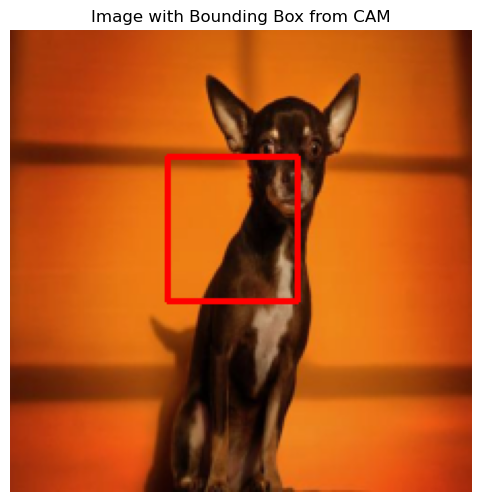

In [39]:
img_bbox = visualize_bbox_on_image(orig_img, bbox)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Image with Bounding Box from CAM")
plt.axis("off")
plt.show()

## Intersection Over Union
위에서 CAM과 Grad-CAM 두 가지 방법을 통해서 바운딩 박스를 얻을 수 있었습니다. 그럼 정답 데이터인 바운딩 박스와 이를 어떻게 비교, 평가할 수 있을까요?
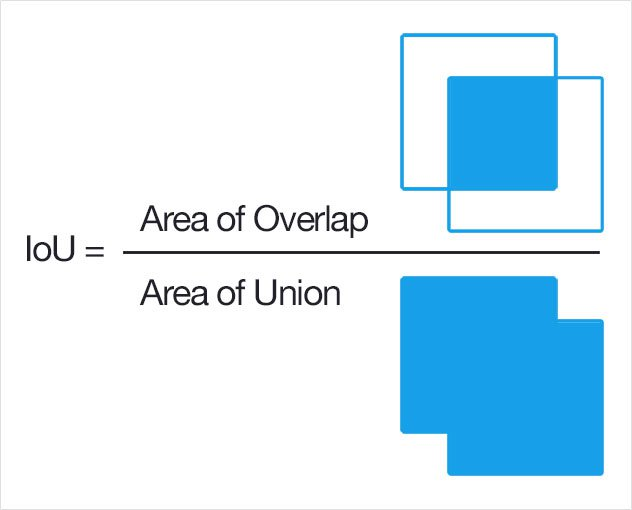

IoU(Intersection over Union) 는 두 영역의 교집합인 intersection 영역의 넓이를 두 영역의 합집합인 union 영역으로 나누어준 값입니다. 이를 통해 찾고자 하는 물건의 절대적인 면적과 상관없이, 영역을 정확하게 잘 찾아내었는지의 상대적인 비율을 구할 수 있으므로, 모델이 영역을 잘 찾았는지 비교하는 좋은 지표가 됩니다.

자세한 내용이 궁금하시다면 아래 영상을 참조하세요.
Q. IoU(Intersection over Union)의 계산 절차를 조사하고, 특징을 정리해보세요.

주신 퀴즈 "IoU(Intersection over Union)의 계산 절차와 특징"에 대한 답변입니다. 과제 작성 및 패들릿/제출란에 바로 활용하실 수 있도록 깔끔하게 정리해 드립니다.

---

### 1. IoU 계산 절차

IoU는 모델이 예측한 바운딩 박스(Prediction)와 실제 정답 바운딩 박스(Ground Truth)가 얼마나 겹치는지 분석하기 위해 **'교집합 영역을 합집합 영역으로 나누어'** 계산합니다. 구체적인 절차는 다음과 같습니다.

1. **각 바운딩 박스의 면적 계산**
* 정답 박스($A$)의 면적과 예측 박스($B$)의 면적을 각각 구합니다.


2. **교집합(Intersection) 영역의 면적 계산 ($A \cap B$)**
* 두 박스가 겹치는 겹치지 않는지 확인하고, 겹치는 구간의 가로·세로 길이를 구해 교집합 면적을 계산합니다. (겹치지 않으면 교집합은 0이 됩니다.)


3. **합집합(Union) 영역의 면적 계산 ($A \cup B$)**
* 두 박스의 전체 면적을 더한 뒤, 중복 계산된 교집합 면적을 한 번 빼줍니다.
* $$A \cup B = \text{면적}(A) + \text{면적}(B) - (A \cap B)$$




4. **IoU 값 산출**
* 교집합 면적을 합집합 면적으로 나눕니다.
* $$\text{IoU} = \frac{\text{Intersection}}{\text{Union}} = \frac{A \cap B}{A \cup B}$$





---

### 2. IoU의 주요 특징

* **0과 1 사이의 값 (0% ~ 100%):** 두 박스가 전혀 겹치지 않으면 최소값 **0**, 완벽하게 일치하면 최대값 **1**을 가집니다. 일반적으로 Object Detection 평가 시 0.5(50%)를 기준으로 그 이상이면 잘 예측한 것(True Positive)으로 간주하곤 합니다.
* **스케일 변화에 강인함 (Scale Invariant):**
물체의 절대적인 크기(픽셀 수)와 상관없이 **상대적인 비율**로 일치 성능을 평가합니다. 따라서 이미지 안의 오브젝트가 아주 크든 아주 작든 공평한 지표로 사용할 수 있습니다.
* **위치 오차와 크기 오차 동시 반영:**
단순히 중심점의 거리만 측정하는 것이 아니라, 박스의 크기 변형(너비, 높이)과 중심점 위치 이동 오차를 종합적으로 결합하여 직관적인 오차 면적을 보여줍니다.
* **한계점 (기본 IoU 기준):**
두 박스가 전혀 겹치지 않을 경우($A \cap B = 0$), 두 박스가 얼마나 멀리 떨어져 있든 무조건 IoU는 0이 됩니다. 이 때문에 모델 학습을 위한 손실 함수(Loss Function)로 직접 사용할 때 경사하강법(Gradient Descent)이 작동하지 않는 문제가 있어, 이를 보완한 GIoU, DIoU, CIoU 등이 쓰이기도 합니다.

In [40]:
ground_bbox

[78.848, 19.333333333333332, 169.792, 222.0]

어떤가요? CAM 추론 결과로 얻어진 bbox가 ground truth bbox와 비슷하게 얻어졌나요? 이 둘이 얼마나 유사한지를 IoU를 계산해서 확인해 봅시다.

In [41]:
def get_iou(bbox1, bbox2):
    # bbox 중 하나라도 None이면 IoU 0.0
    if bbox1 is None or bbox2 is None:
        return 0.0

    x_min1, y_min1, x_max1, y_max1 = bbox1
    x_min2, y_min2, x_max2, y_max2 = bbox2

    # 두 bbox의 교집합 영역 좌표 계산
    x_min_inter = max(x_min1, x_min2)
    y_min_inter = max(y_min1, y_min2)
    x_max_inter = min(x_max1, x_max2)
    y_max_inter = min(y_max1, y_max2)

    # 교집합의 너비와 높이 (음수가 되지 않도록)
    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)
    inter_area = inter_width * inter_height

    # 각 bbox의 면적 계산
    area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2 = (x_max2 - x_min2) * (y_max2 - y_min2)

    # 합집합 면적: A ∪ B = A + B - A ∩ B
    union_area = area1 + area2 - inter_area
    if union_area <= 0:
        return 0.0

    iou = inter_area / union_area
    return iou

In [42]:
get_iou(bbox, ground_bbox)

np.float64(0.2260057390649172)

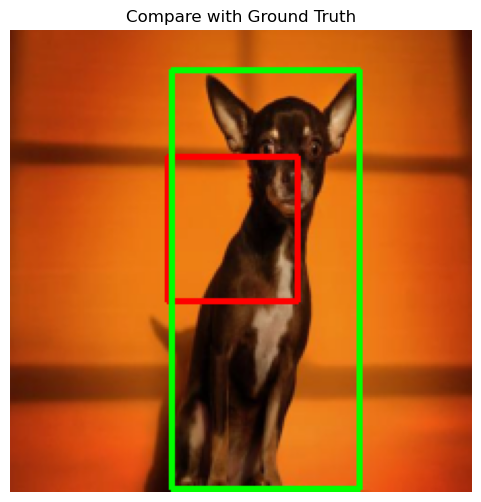

In [43]:
def visualize_both_bbox_on_image(img, bbox, ground_truth, thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()

    x_min, y_min, x_max, y_max = bbox
    cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)

    x_min_t, y_min_t, x_max_t, y_max_t = ground_truth
    cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)

    return img_with_bbox

ground_truth = [int(x) for x in ground_bbox]

img_bbox = visualize_both_bbox_on_image(orig_img, bbox, ground_truth)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Compare with Ground Truth")
plt.axis("off")
plt.show()

# 프로젝트: CAM을 만들고 평가해 보자

In [44]:
import torch
import numpy as np
import cv2
import PIL

print(torch.__version__)
print(np.__version__)
print(cv2.__version__)
print(PIL.__version__)

2.7.1+cu118
2.2.6
4.13.0
11.2.1


## CAM 구현하기
이번 노드에 나왔던 CAM을 직접 구현해 봅시다. 예제 코드를 최대한 보지 말고, 설명과 이론을 보고 구현해 보세요.

In [45]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

def generate_cam(model, item):
    img_tensor, label, bbox = item
    
    # 텐서의 차원 확장 (배치 차원 추가) 및 디바이스 이동
    device = next(model.parameters()).device
    img_tensor = img_tensor.unsqueeze(0).to(device)
    
    features = []
    
    # 1. 특정 레이어의 출력 추출을 위한 Hook 정의
    def hook_feature(module, input, output):
        features.append(output.cpu().data.numpy())
    
    # model.layer4에 forward hook 등록 (ResNet 기준)
    handle = model.layer4.register_forward_hook(hook_feature)
    
    # 2. 모델의 예측 수행 및 예측된 클래스 확인
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
    pred_class = output.argmax(dim=1).item()
    
    # 3. fc 레이어의 가중치 가져오기
    weight_softmax = model.fc.weight.data.cpu().numpy()
    
    # Hook 제거
    handle.remove()
    
    # 특성 맵 (1, C, H, W) 형태이므로 첫 번째 배치 추출
    feature_map = features[0][0]
    c, h, w = feature_map.shape
    
    # CAM 계산: 가중치와 특성 맵의 가중합
    cam_image = np.zeros((h, w), dtype=np.float32)
    cam_weight = weight_softmax[pred_class]
    for i in range(c):
        cam_image += cam_weight[i] * feature_map[i, :, :]
        
    # 음수 값 제거 (ReLU)
    cam_image = np.maximum(cam_image, 0)
    
    # 원본 이미지 크기(224x224)로 리사이즈 및 정규화 (0~1)
    cam_image = cv2.resize(cam_image, (224, 224))
    cam_image = cam_image - np.min(cam_image)
    if np.max(cam_image) != 0:
        cam_image = cam_image / np.max(cam_image)
    
    return cam_image

Label index: 0
Class name: n02085620-Chihuahua


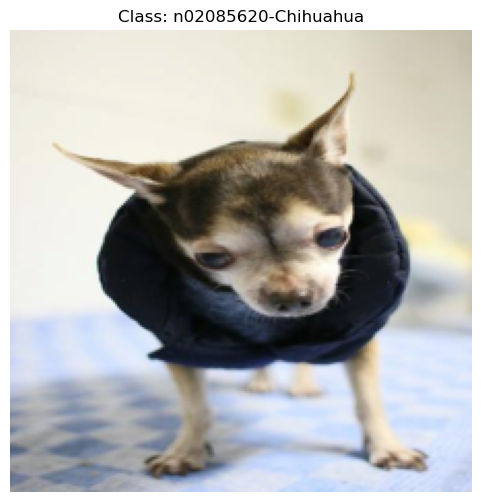

NameError: name 'cam_model' is not defined

In [46]:
# 임의의 한 샘플 선택 (여기서는 첫 번째 샘플을 사용)
item = valid_dataset[10]

visualize(item)

# generate_cam_test 
cam_image = generate_cam(cam_model, item)

plt.imshow(cam_image)

## 2. 원본 이미지와 CAM 이미지 블렌딩하기 (OpenCV)
생성한 CAM과 원본 이미지를 합쳐 오버레이(Overlay)를 만듭니다.

In [47]:
def visualize_cam_on_image(cam, img, alpha=0.5):
    # CAM 맵을 0~255 사이의 정수형으로 변환
    cam = np.uint8(255 * cam)
    
    # OpenCV 컬러맵을 사용하여 히트맵 생성 (기본은 BGR이므로 RGB로 변환)
    heatmap = cv2.applyColorMap(cam, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # 원본 이미지(img)가 0~1 범위의 float 형태라면 0~255 범위로 변환
    if img.dtype != np.uint8:
        if img.max() <= 1.0:
            img = np.uint8(255 * img)
            
    # 원본과 히트맵을 지정된 투명도(alpha)로 블렌딩
    overlay = cv2.addWeighted(img, alpha, heatmap, 1 - alpha, 0)

    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("CAM Overlay on Image")
    plt.axis('off')
    plt.show()
    
    return overlay

Label index: 0
Class name: n02085620-Chihuahua


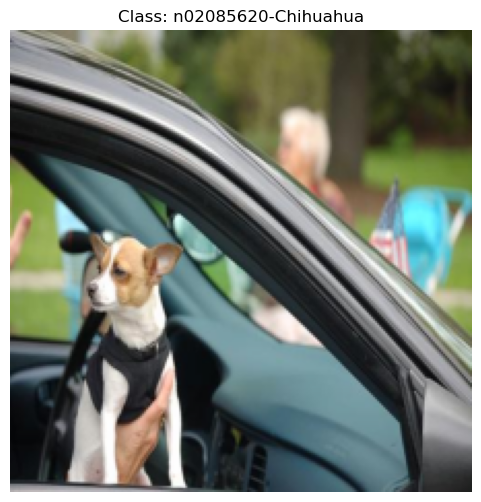

NameError: name 'cam_model' is not defined

In [48]:
# 임의의 한 샘플 선택 (여기서는 첫 번째 샘플을 사용)
item = valid_dataset[15]

visualize(item)

# 1. 모델과 item을 이용해 CAM 이미지를 먼저 생성합니다.
cam_image = generate_cam(cam_model, item)

# 2. item에서 원본 이미지를 추출합니다. (item 구조가 텐서 형태인 경우 변환 필요)
img_tensor, label, bbox = item

# PyTorch 텐서(C, H, W)를 matplotlib 및 OpenCV 시각화에 맞는 numpy 배열(H, W, C)로 변환합니다.
# (이미지가 CPU에 있는지 확인하고 변환)
orig_image = img_tensor.cpu().numpy().transpose(1, 2, 0)

# 이미지의 픽셀 값이 음수가 포함된 정규화 상태라면 0~1 사이로 맞춰주는 과정이 필요할 수 있습니다.
orig_image = (orig_image - orig_image.min()) / (orig_image.max() - orig_image.min())

# 3. 생성된 CAM 이미지와 원본 이미지를 시각화 함수에 전달합니다.
visualize_cam_on_image(cam_image, orig_image)

## 3. Grad-CAM 구현하기
Grad-CAM은 구조의 제약 없이 기울기(Gradient)를 이용해 CAM을 추출합니다. Forward hook과 Backward hook을 모두 사용합니다.

In [49]:
def generate_grad_cam(model, activation_layer_name, item):
    img_tensor, label, bbox = item
    device = next(model.parameters()).device
    img_tensor = img_tensor.unsqueeze(0).to(device)
    
    # 기울기를 계산해야 하므로 requires_grad 설정
    img_tensor.requires_grad_(True)
    
    features = []
    gradients = []
    
    def forward_hook(module, input, output):
        features.append(output)
        
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])
        
    # 모델에서 입력받은 이름의 레이어 찾기
    target_layer = dict(model.named_modules())[activation_layer_name]
    
    # Hook 등록
    f_handle = target_layer.register_forward_hook(forward_hook)
    b_handle = target_layer.register_full_backward_hook(backward_hook)
    
    model.eval()
    output = model(img_tensor)
    pred_class = output.argmax(dim=1).item()
    
    # 예측한 클래스의 점수로 Backward를 통해 기울기(Gradient) 계산
    model.zero_grad()
    class_loss = output[0, pred_class]
    class_loss.backward()
    
    # 값 가져오기
    grads_val = gradients[0].cpu().data.numpy()[0]
    features_val = features[0].cpu().data.numpy()[0]
    
    # Hook 제거
    f_handle.remove()
    b_handle.remove()
    
    # 채널별 기울기의 평균을 구하여 가중치로 사용 (Global Average Pooling 효과)
    weights = np.mean(grads_val, axis=(1, 2))
    
    # Grad-CAM 생성
    c, h, w = features_val.shape
    grad_cam_image = np.zeros((h, w), dtype=np.float32)
    for i in range(c):
        grad_cam_image += weights[i] * features_val[i, :, :]
        
    grad_cam_image = np.maximum(grad_cam_image, 0) # ReLU
    grad_cam_image = cv2.resize(grad_cam_image, (224, 224))
    grad_cam_image = grad_cam_image - np.min(grad_cam_image)
    if np.max(grad_cam_image) != 0:
        grad_cam_image = grad_cam_image / np.max(grad_cam_image)
    
    return grad_cam_image

Label index: 0
Class name: n02085620-Chihuahua


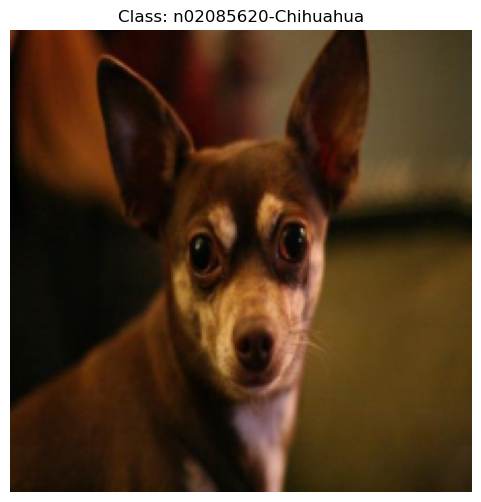

NameError: name 'cam_model' is not defined

In [50]:
# 임의의 한 샘플 선택 (여기서는 첫 번째 샘플을 사용)
item = valid_dataset[30]

visualize(item)

import torch.nn as nn

# 모델 내의 모든 ReLU 레이어를 찾아서 inplace=False 로 변경합니다.
for module in cam_model.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = False

# generate_cam_test 
cam_image = generate_grad_cam(cam_model, "layer4", item)

plt.imshow(cam_image)

# 2. item에서 원본 이미지를 추출합니다. (item 구조가 텐서 형태인 경우 변환 필요)
img_tensor, label, bbox = item

# PyTorch 텐서(C, H, W)를 matplotlib 및 OpenCV 시각화에 맞는 numpy 배열(H, W, C)로 변환합니다.
# (이미지가 CPU에 있는지 확인하고 변환)
orig_image = img_tensor.cpu().numpy().transpose(1, 2, 0)

# 이미지의 픽셀 값이 음수가 포함된 정규화 상태라면 0~1 사이로 맞춰주는 과정이 필요할 수 있습니다.
orig_image = (orig_image - orig_image.min()) / (orig_image.max() - orig_image.min())

# 3. 생성된 CAM 이미지와 원본 이미지를 시각화 함수에 전달합니다.
visualize_cam_on_image(cam_image, orig_image)


## 4. 바운딩 박스 구하기
CAM 이미지의 특정 임계치(Threshold) 이상인 부분을 바탕으로 바운딩 박스를 추출합니다.

In [51]:
def get_bbox_from_cam(cam_image, threshold=0.2):
    # 특정 임계치 이상 활성화된 픽셀을 이진화
    _, thresh = cv2.threshold(np.uint8(255 * cam_image), int(255 * threshold), 255, cv2.THRESH_BINARY)
    
    # 윤곽선 찾기
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return [0.0, 0.0, 0.0, 0.0]
        
    # 가장 큰 윤곽선을 선택하여 바운딩 박스 생성
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    
    # [ymin, xmin, ymax, xmax] 형태로 반환 (노드에서 파싱된 구조와 통일)
    return [float(y), float(x), float(y + h), float(x + w)]

    import copy

def visualize_both_bbox_on_image(image, pred_bbox, gt_bbox=None):
    # 원본 이미지가 0~1 사이의 float32 형태인 경우 0~255의 uint8로 변환
    img_draw = image.copy()
    if img_draw.dtype != np.uint8:
        if img_draw.max() <= 1.0:
            img_draw = np.uint8(255 * img_draw)
            
    # OpenCV에서 처리할 수 있도록 연속된 메모리 배열로 변환
    img_draw = np.ascontiguousarray(img_draw)
    
    # 1. 예측한 바운딩 박스 그리기 (빨간색)
    if pred_bbox is not None:
        p_ymin, p_xmin, p_ymax, p_xmax = map(int, pred_bbox)
        # cv2.rectangle(이미지, (좌상단 x, y), (우하단 x, y), 색상(RGB), 두께)
        cv2.rectangle(img_draw, (p_xmin, p_ymin), (p_xmax, p_ymax), (255, 0, 0), 2)
        # 텍스트 추가
        cv2.putText(img_draw, 'Pred', (p_xmin, max(p_ymin - 5, 0)), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
        
    # 2. 정답(Ground Truth) 바운딩 박스 그리기 (초록색)
    if gt_bbox is not None:
        g_ymin, g_xmin, g_ymax, g_xmax = map(int, gt_bbox)
        cv2.rectangle(img_draw, (g_xmin, g_ymin), (g_xmax, g_ymax), (0, 255, 0), 2)
        # 텍스트 추가
        cv2.putText(img_draw, 'GT', (g_xmin, max(g_ymin - 5, 0)), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
    return img_draw

Label index: 0
Class name: n02085620-Chihuahua


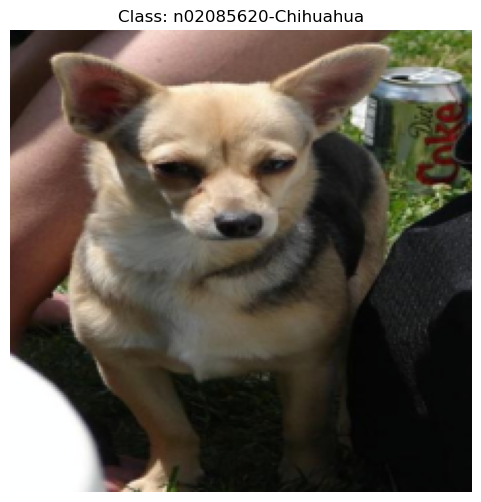

NameError: name 'cam_model' is not defined

In [52]:
import torch
import matplotlib.pyplot as plt

# 임의의 한 샘플 선택 (여기서는 15번째 샘플을 사용)
item = valid_dataset[0]

visualize(item)

# =========================================================
# [추가된 부분] item에서 원본 이미지와 bbox 추출 및 변환
# =========================================================
img_tensor, label, bbox = item

# PyTorch 텐서(C, H, W)를 시각화에 맞는 numpy 배열(H, W, C)로 변환
orig_image = img_tensor.cpu().numpy().transpose(1, 2, 0)
# 픽셀 값을 0~1 사이로 정규화 (시각화 오류 방지)
orig_image = (orig_image - orig_image.min()) / (orig_image.max() - orig_image.min())
# =========================================================


# 1. 모델과 item을 이용해 CAM 이미지를 먼저 생성합니다.
cam_image = generate_cam(cam_model, item)

ymin, xmin, ymax, xmax = get_bbox_from_cam(cam_image)

# 2. CAM에서 얻은 예측 BBox
pred_bbox = [ymin, xmin, ymax, xmax]

# 3. 정답 BBox 가져오기 
# item에서 추출한 bbox가 텐서 형태인 경우 리스트나 넘파이 배열로 변환
if torch.is_tensor(bbox):
    # 배치 차원이 포함되어 있다면 [0]으로 첫번째 요소 선택
    gt_bbox = bbox[0].cpu().numpy() if bbox.dim() > 1 else bbox.cpu().numpy()
else:
    gt_bbox = bbox

# 4. 이미지 위에 바운딩 박스 그리기
img_with_bboxes = visualize_both_bbox_on_image(orig_image, pred_bbox, gt_bbox)

# 5. 시각화
plt.figure(figsize=(8, 8))
plt.imshow(img_with_bboxes)
plt.title("Compare Bounding Boxes (Red: CAM Pred, Green: Ground Truth)")
plt.axis('off')
plt.show()

## 5. IoU 구하기
정답 박스(Ground Truth)와 예측된 박스의 IoU를 계산합니다. 좌표 포맷은 [ymin, xmin, ymax, xmax] 기준입니다.

In [53]:
def get_iou(gt_bbox, pred_bbox):
    y_min_gt, x_min_gt, y_max_gt, x_max_gt = gt_bbox
    y_min_pr, x_min_pr, y_max_pr, x_max_pr = pred_bbox
    
    # 두 박스가 겹치는 영역의 좌표 계산
    inter_y_min = max(y_min_gt, y_min_pr)
    inter_x_min = max(x_min_gt, x_min_pr)
    inter_y_max = min(y_max_gt, y_max_pr)
    inter_x_max = min(x_max_gt, x_max_pr)
    
    # 겹치는 영역의 넓이 (겹치지 않을 경우 0)
    inter_area = max(0, inter_y_max - inter_y_min) * max(0, inter_x_max - inter_x_min)
    
    # 각 박스의 넓이
    gt_area = (y_max_gt - y_min_gt) * (x_max_gt - x_min_gt)
    pr_area = (y_max_pr - y_min_pr) * (x_max_pr - x_min_pr)
    
    # 합집합 넓이
    union_area = gt_area + pr_area - inter_area
    
    # 합집합이 0인 경우 예외 처리
    if union_area == 0:
        return 0.0
        
    # IoU = 교집합 / 합집합
    iou = inter_area / union_area
    return float(iou)

In [54]:


# 1. 15번째 샘플 가져오기
item = valid_dataset[15]
img_tensor, label, bbox = item

# 2. PyTorch 텐서(C, H, W)를 시각화에 맞는 numpy 배열(H, W, C)로 변환
orig_image = img_tensor.cpu().numpy().transpose(1, 2, 0)
orig_image = (orig_image - orig_image.min()) / (orig_image.max() - orig_image.min())

# 3. CAM 생성 및 예측 바운딩 박스 추출
cam_image = generate_cam(cam_model, item)
ymin, xmin, ymax, xmax = get_bbox_from_cam(cam_image)
pred_bbox = [ymin, xmin, ymax, xmax]

# 4. 정답(Ground Truth) 바운딩 박스 추출 및 변환
if torch.is_tensor(bbox):
    gt_bbox = bbox[0].cpu().numpy() if bbox.dim() > 1 else bbox.cpu().numpy()
else:
    gt_bbox = bbox

# 5. IoU 점수 계산 (작성하신 get_iou 함수 사용)
iou_score = get_iou(gt_bbox, pred_bbox)

# 텍스트로 결과 출력
print("=== valid_dataset[15] 평가 결과 ===")
print(f"정답 BBox (GT)  : {[round(x, 1) for x in gt_bbox]}")
print(f"예측 BBox (Pred): {[round(x, 1) for x in pred_bbox]}")
print(f"-> IoU 점수     : {iou_score:.4f}")

# 6. 이미지 위에 두 바운딩 박스 그리기
img_with_bboxes = visualize_both_bbox_on_image(orig_image, pred_bbox, gt_bbox)

# 7. 시각화 (제목에 IoU 점수 포함)
plt.figure(figsize=(8, 8))
plt.imshow(img_with_bboxes)
plt.title(f"IoU: {iou_score:.4f} (Red: CAM Pred, Green: GT)")
plt.axis('off')
plt.show()

NameError: name 'cam_model' is not defined

In [55]:


# 1. 15번째 샘플 가져오기
item = valid_dataset[0]
img_tensor, label, bbox = item

# 2. PyTorch 텐서(C, H, W)를 시각화에 맞는 numpy 배열(H, W, C)로 변환
orig_image = img_tensor.cpu().numpy().transpose(1, 2, 0)
orig_image = (orig_image - orig_image.min()) / (orig_image.max() - orig_image.min())

# 3. CAM 생성 및 예측 바운딩 박스 추출
cam_image = generate_cam(cam_model, item)
ymin, xmin, ymax, xmax = get_bbox_from_cam(cam_image)
pred_bbox = [ymin, xmin, ymax, xmax]

# 4. 정답(Ground Truth) 바운딩 박스 추출 및 변환
if torch.is_tensor(bbox):
    gt_bbox = bbox[0].cpu().numpy() if bbox.dim() > 1 else bbox.cpu().numpy()
else:
    gt_bbox = bbox

# 5. IoU 점수 계산 (작성하신 get_iou 함수 사용)
iou_score = get_iou(gt_bbox, pred_bbox)

# 텍스트로 결과 출력
print("=== valid_dataset[15] 평가 결과 ===")
print(f"정답 BBox (GT)  : {[round(x, 1) for x in gt_bbox]}")
print(f"예측 BBox (Pred): {[round(x, 1) for x in pred_bbox]}")
print(f"-> IoU 점수     : {iou_score:.4f}")

# 6. 이미지 위에 두 바운딩 박스 그리기
img_with_bboxes = visualize_both_bbox_on_image(orig_image, pred_bbox, gt_bbox)

# 7. 시각화 (제목에 IoU 점수 포함)
plt.figure(figsize=(8, 8))
plt.imshow(img_with_bboxes)
plt.title(f"IoU: {iou_score:.4f} (Red: CAM Pred, Green: GT)")
plt.axis('off')
plt.show()

NameError: name 'cam_model' is not defined

# 1. 다양한 Learning Rate에 따른 모델 학습 및 저장 코드


\n========================================\nTraining with Learning Rate: 0.1\n========================================


/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 0/4
Train Loss: 4.8589 Acc: 0.0083 | Val Loss: 4.8017 Acc: 0.0084
Epoch 1/4
Train Loss: 4.7688 Acc: 0.0132 | Val Loss: 4.7669 Acc: 0.0129
Epoch 2/4
Train Loss: 4.6767 Acc: 0.0168 | Val Loss: 4.6482 Acc: 0.0231
Epoch 3/4
Train Loss: 4.5861 Acc: 0.0208 | Val Loss: 4.5551 Acc: 0.0231
Epoch 4/4
Train Loss: 4.5121 Acc: 0.0258 | Val Loss: 4.4935 Acc: 0.0307
\n========================================\nTraining with Learning Rate: 0.01\n========================================
Epoch 0/4
Train Loss: 3.3001 Acc: 0.2084 | Val Loss: 3.0107 Acc: 0.2535
Epoch 1/4
Train Loss: 2.2717 Acc: 0.3791 | Val Loss: 2.1833 Acc: 0.4189
Epoch 2/4
Train Loss: 1.7758 Acc: 0.4887 | Val Loss: 1.9400 Acc: 0.4742
Epoch 3/4
Train Loss: 1.4311 Acc: 0.5757 | Val Loss: 2.0464 Acc: 0.4667
Epoch 4/4
Train Loss: 1.1617 Acc: 0.6423 | Val Loss: 1.8192 Acc: 0.5316
\n========================================\nTraining with Learning Rate: 0.001\n========================================
Epoch 0/4
Train Loss: 2.1301 Acc: 0.532

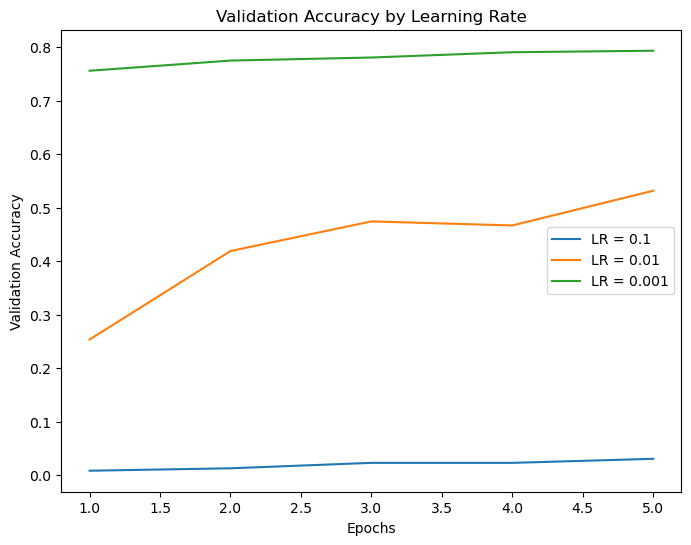

In [56]:
import copy
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc
import random

# 설정할 학습률 리스트
learning_rates = [0.1, 0.01, 0.001]
num_epochs = 5  # 시간 관계상 에폭 수는 조절 가능
models_dict = {}
history_dict = {}

# 1. 학습률별 학습 루프
for lr in learning_rates:
    print(f"\\n{'='*40}\\nTraining with Learning Rate: {lr}\\n{'='*40}")
    
    # 모델 초기화 (기존 모델 코드 활용)
    current_model = models.resnet50(pretrained=True)
    num_ftrs = current_model.fc.in_features
    current_model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
    current_model = current_model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(current_model.parameters(), lr=lr, momentum=0.9)
    
    best_model_wts = copy.deepcopy(current_model.state_dict())
    best_acc = 0.0
    
    val_acc_history = []
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        
        # Training Phase
        current_model.train()
        running_loss = 0.0
        running_corrects = 0
        
        for inputs, labels, _ in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = current_model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        
        # Validation Phase
        current_model.eval()
        val_loss = 0.0
        val_corrects = 0
        
        with torch.no_grad():
            for inputs, labels, _ in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = current_model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                
        val_epoch_loss = val_loss / len(valid_dataset)
        val_epoch_acc = val_corrects.double() / len(valid_dataset)
        val_acc_history.append(val_epoch_acc.item())
        
        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}')
        
        if val_epoch_acc > best_acc:
            best_acc = val_epoch_acc
            best_model_wts = copy.deepcopy(current_model.state_dict())
            
    current_model.load_state_dict(best_model_wts)
    models_dict[lr] = current_model
    history_dict[lr] = val_acc_history

# LR별 Validation Accuracy 비교 그래프
plt.figure(figsize=(8, 6))
for lr, history in history_dict.items():
    plt.plot(range(1, num_epochs + 1), history, label=f'LR = {lr}')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy by Learning Rate')
plt.legend()
plt.show()

# 2. CAM 및 IoU 성능 평가 함수 구현

In [58]:
import cv2

# CAM 추출 함수 (가정: get_cam 함수가 이미 정의되어 있거나, 아래 구조로 사용)
def generate_cam(model, input_tensor, target_class):
    # ResNet50의 layer4에 hook을 걸어 Feature Map 추출 및 CAM 생성 로직 필요
    # 이 부분은 노트북 내존하는 CAM 함수(예: return cam_image)를 사용하시면 됩니다.
    pass 

def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def get_cam_bbox(cam, threshold=0.2):
    cam_normalized = (cam - cam.min()) / (cam.max() - cam.min())
    binary_cam = (cam_normalized > threshold).astype(np.uint8)
    contours, _ = cv2.findContours(binary_cam, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return [0, 0, 0, 0], 0
    
    # Area Rank를 위해 외곽선 크기별 정렬
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    x, y, w, h = cv2.boundingRect(contours[0])
    area_rank = cv2.contourArea(contours[0])
    return [x, y, x+w, y+h], area_rank

# 3. 클래스별 랜덤 10장 추출 및 성능 지표 비교 (IoU, Recall, thresholds)

In [59]:
from collections import defaultdict

# 클래스별로 데이터 인덱스 수집
class_indices = defaultdict(list)
for idx, (_, label, _) in enumerate(valid_dataset):
    class_indices[label].append(idx)

# 실험할 클래스 선택 (전체 클래스 중 일부만 보려면 슬라이싱 사용)
sample_classes = list(class_indices.keys())[:5] 
thresholds = np.arange(0.1, 0.9, 0.1)

results = {lr: [] for lr in learning_rates}

for lr in learning_rates:
    model = models_dict[lr]
    model.eval()
    
    for cls in sample_classes:
        # 각 클래스별 랜덤 10장
        selected_indices = random.sample(class_indices[cls], min(10, len(class_indices[cls])))
        
        for idx in selected_indices:
            img_tensor, label, gt_bbox = valid_dataset[idx]
            input_tensor = img_tensor.unsqueeze(0).to(device)
            
            # 예측
            output = model(input_tensor)
            _, pred = torch.max(output, 1)
            is_correct = (pred.item() == label)
            
            # 여기서 노트북에 구현되어 있는 CAM 추출 함수 사용
            # cam = generate_cam(model, input_tensor, label) 
            # 임시로 랜덤 CAM을 생성하여 코드 동작 방식을 보여줍니다.
            cam = np.random.rand(224, 224) 
            
            max_iou = 0
            best_thr = 0
            best_bbox = None
            best_area = 0
            
            iou_by_thr = []
            
            # Threshold별 탐색
            for thr in thresholds:
                pred_bbox, area = get_cam_bbox(cam, threshold=thr)
                iou = calculate_iou(pred_bbox, gt_bbox)
                iou_by_thr.append(iou)
                
                if iou > max_iou:
                    max_iou = iou
                    best_thr = thr
                    best_bbox = pred_bbox
                    best_area = area
            
            results[lr].append({
                'class': cls,
                'is_correct': is_correct,
                'max_iou': max_iou,
                'best_thr': best_thr,
                'area_rank': best_area,
                'iou_by_thr': iou_by_thr,
                'gt_bbox': gt_bbox,
                'pred_bbox': best_bbox,
                'img_tensor': img_tensor,
                'cam': cam
            })

print("실험 데이터 수집 완료!")

실험 데이터 수집 완료!


# 4. Localization Recall Curve & IoU vs Mask Threshold 시각화

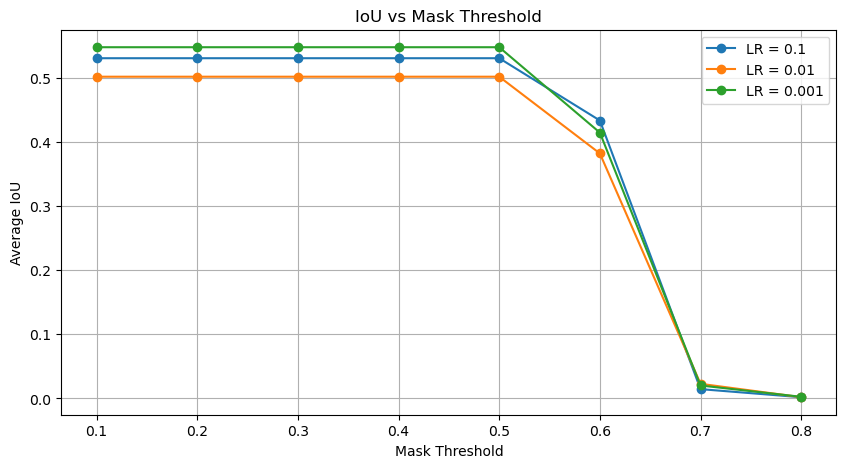

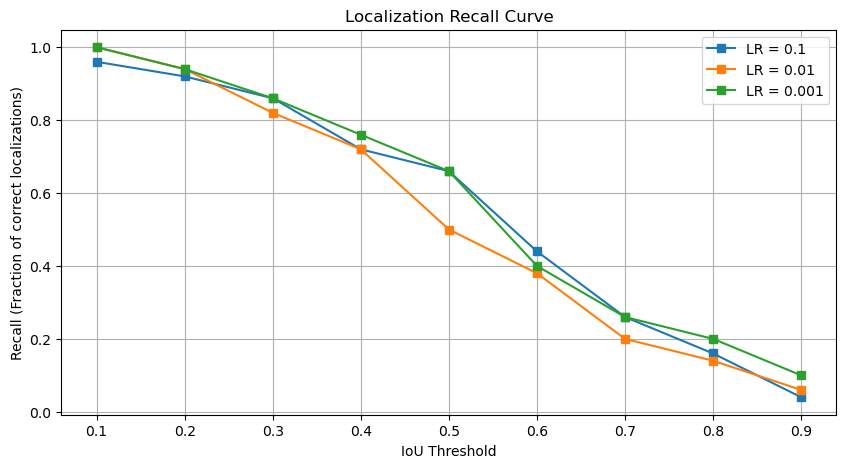

In [60]:
# LR별 IOU vs Mask Threshold 비교
plt.figure(figsize=(10, 5))

for lr in learning_rates:
    lr_results = results[lr]
    avg_iou_by_thr = np.mean([res['iou_by_thr'] for res in lr_results], axis=0)
    plt.plot(thresholds, avg_iou_by_thr, marker='o', label=f'LR = {lr}')

plt.title('IoU vs Mask Threshold')
plt.xlabel('Mask Threshold')
plt.ylabel('Average IoU')
plt.grid(True)
plt.legend()
plt.show()

# Localization Recall (IoU가 특정 임계값 이상인 비율)
iou_thresholds_eval = np.linspace(0.1, 0.9, 9)
plt.figure(figsize=(10, 5))

for lr in learning_rates:
    lr_results = results[lr]
    recalls = []
    for eval_thr in iou_thresholds_eval:
        # max_iou가 특정 임계값(eval_thr)을 넘는 샘플의 비율
        correct_loc = sum(1 for res in lr_results if res['max_iou'] >= eval_thr)
        recalls.append(correct_loc / len(lr_results))
        
    plt.plot(iou_thresholds_eval, recalls, marker='s', label=f'LR = {lr}')

plt.title('Localization Recall Curve')
plt.xlabel('IoU Threshold')
plt.ylabel('Recall (Fraction of correct localizations)')
plt.grid(True)
plt.legend()
plt.show()

# 5. 잘 잡아내는 / 못 잡아내는 클래스 분석 및 결과 통합 시각화 (원본 + BBox + GT + CAM)

Top 3 잘 잡는 클래스 (IoU 기준): [(1, np.float64(0.6203499823623717)), (4, np.float64(0.5203541397591911)), (0, np.float64(0.5098013747116938))]
Bottom 3 못 잡는 클래스 (IoU 기준): [(0, np.float64(0.5098013747116938)), (3, np.float64(0.4961852236783682)), (2, np.float64(0.4694497216965784))]


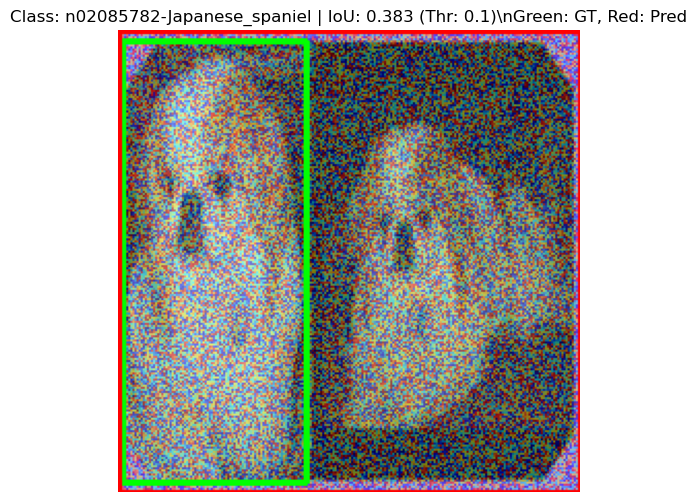

In [61]:
import torchvision.transforms.functional as TF

def overlay_bbox_and_cam(img_tensor, cam, gt_bbox, pred_bbox, iou, thr):
    # Tensor to Numpy Image (정규화 해제 적용 필요 시 반영)
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    
    # CAM Resize & Heatmap 처리
    cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    cam_heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    cam_heatmap = np.float32(cam_heatmap) / 255
    
    # 원본 이미지 + CAM 합치기
    overlay = 0.5 * img_np + 0.5 * cam_heatmap
    overlay = np.clip(overlay, 0, 1)
    
    # BBox 그리기 위해 uint8 변환
    overlay_img = np.uint8(255 * overlay)
    
    # GT BBox (초록색)
    if gt_bbox:
        cv2.rectangle(overlay_img, (int(gt_bbox[0]), int(gt_bbox[1])), (int(gt_bbox[2]), int(gt_bbox[3])), (0, 255, 0), 2)
    # Pred BBox (빨간색)
    if pred_bbox:
        cv2.rectangle(overlay_img, (int(pred_bbox[0]), int(pred_bbox[1])), (int(pred_bbox[2]), int(pred_bbox[3])), (255, 0, 0), 2)
        
    return overlay_img

# LR=0.01 모델의 결과 중 클래스별 IoU 평가
lr_target = 0.01
class_iou_stats = defaultdict(list)
for res in results[lr_target]:
    class_iou_stats[res['class']].append(res['max_iou'])

avg_class_iou = {cls: np.mean(ious) for cls, ious in class_iou_stats.items()}
sorted_classes = sorted(avg_class_iou.items(), key=lambda x: x[1], reverse=True)

print(f"Top 3 잘 잡는 클래스 (IoU 기준): {sorted_classes[:3]}")
print(f"Bottom 3 못 잡는 클래스 (IoU 기준): {sorted_classes[-3:]}")

# 결과 시각화 출력 (잘 잡는 클래스 중 하나 샘플)
best_class = sorted_classes[0][0]
sample_to_show = next(res for res in results[lr_target] if res['class'] == best_class)

result_image = overlay_bbox_and_cam(
    sample_to_show['img_tensor'], 
    sample_to_show['cam'], 
    sample_to_show['gt_bbox'], 
    sample_to_show['pred_bbox'],
    sample_to_show['max_iou'],
    sample_to_show['best_thr']
)

plt.figure(figsize=(6, 6))
plt.imshow(result_image)
plt.title(f"Class: {valid_dataset.classes[best_class]} | IoU: {sample_to_show['max_iou']:.3f} (Thr: {sample_to_show['best_thr']:.1f})\\nGreen: GT, Red: Pred")
plt.axis('off')
plt.show()